# Medical Image Classification
**MedMNIST** · EfficientNet-B3 · ResNet50 · DenseNet121  
Modalities: Skin · Chest · Eye (OCT) · Brain (Organ-S)

## 1. Setup

In [1]:
!pip install medmnist timm seaborn scikit-learn tqdm -q

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader
from torchvision import transforms
import torchvision.models as models
import timm

import medmnist
from medmnist import INFO

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    precision_recall_fscore_support,
    roc_auc_score, cohen_kappa_score
)

import os
from tqdm.auto import tqdm
import copy
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

print("✅ Imports ready")

d:\MedAi-4-classifiers\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Imports ready


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_WORKERS = 0  # keep 0 to avoid multiprocessing fork errors in Colab/Kaggle

print(f"Device : {device}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"Memory : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"Workers: {NUM_WORKERS}")

Device : cpu
Workers: 0


## 2. Configuration

In [4]:
modalities = ["skin", "chest", "oct", "organ_s"]

dataset_map = {
    "skin":    "dermamnist",
    "chest":   "chestmnist",
    "oct":     "octmnist",
    "organ_s": "organsmnist"
}

backend_modality_map = {
    "skin":    "skin",
    "chest":   "chest",
    "oct":     "eye",
    "organ_s": "brain"
}

model_list = ["resnet", "densenet", "efficientnet"]

BATCH_SIZE           = 32
LEARNING_RATE        = 3e-4
MAX_EPOCHS           = 20
PATIENCE             = 3
CONFIDENCE_THRESHOLD = 0.6

print(f"Modalities : {modalities}")
print(f"Models     : {model_list}")
print(f"Batch size : {BATCH_SIZE} | LR: {LEARNING_RATE} | Epochs: {MAX_EPOCHS}")

Modalities : ['skin', 'chest', 'oct', 'organ_s']
Models     : ['resnet', 'densenet', 'efficientnet']
Batch size : 32 | LR: 0.0003 | Epochs: 20


## 3. Data Pipeline

### 3a. Dataset Overview

In [5]:
from medmnist import INFO
import importlib

print(f"{chr(39)*75}")
print(f"  {'Modality':<12} {'Dataset':<16} {'Task':<25} {'Classes':<9} {'Train':<8} {'Val':<7} {'Test'}")
print(f"{chr(39)*75}")
for modality, data_flag in dataset_map.items():
    info = INFO[data_flag]
    n_classes = len(info["label"])
    splits = info.get("n_samples", {})
    task = info["task"]
    ml = "multi-label" in task
    print(f"  {modality:<12} {data_flag:<16} {task:<25} {n_classes:<9} "
          f"{splits.get('train','?'):<8} {splits.get('val','?'):<7} {splits.get('test','?')}  "
          f"{'[multi-label]' if ml else ''}")


'''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''
  Modality     Dataset          Task                      Classes   Train    Val     Test
'''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''
  skin         dermamnist       multi-class               7         7007     1003    2005  
  chest        chestmnist       multi-label, binary-class 14        78468    11219   22433  [multi-label]
  oct          octmnist         multi-class               4         97477    10832   1000  
  organ_s      organsmnist      multi-class               11        13932    2452    8827  


### 3b. Sample Images per Modality

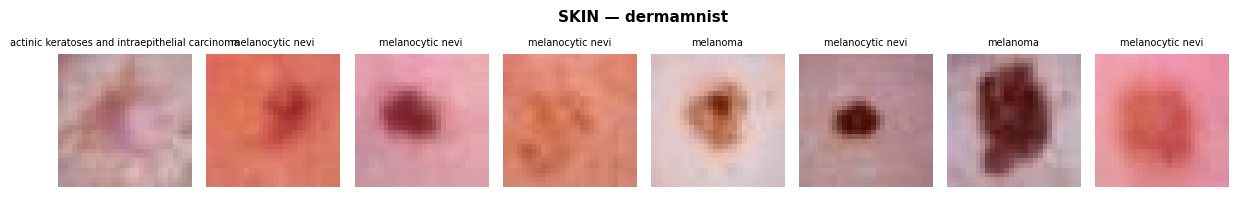

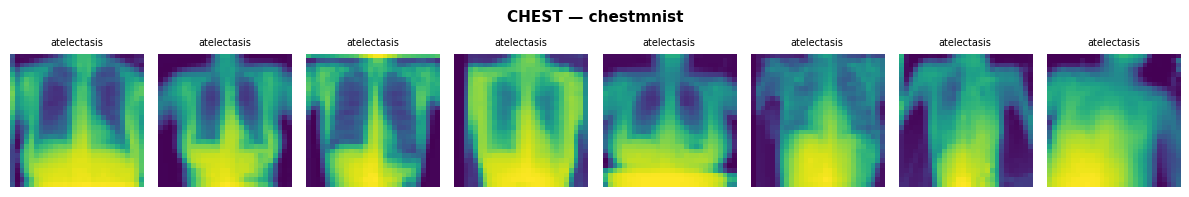

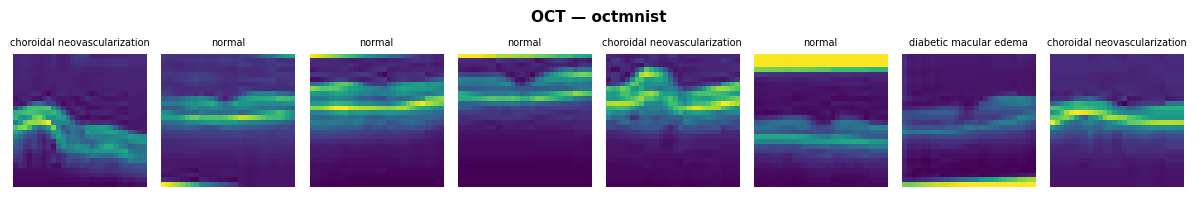

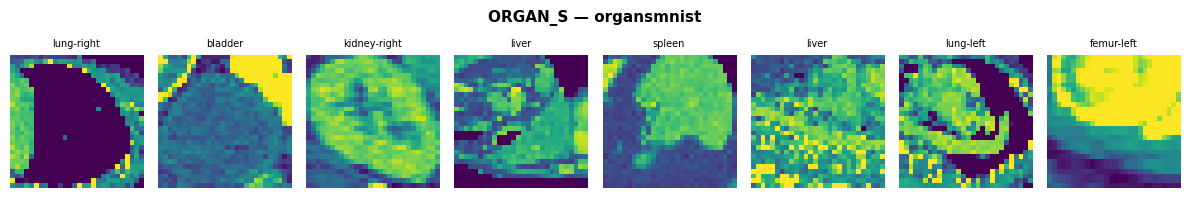

In [6]:
from PIL import Image
import importlib

def show_modality_samples(modality_key, n_samples=8):
    data_flag = dataset_map[modality_key]
    info      = INFO[data_flag]
    DataCls   = getattr(medmnist, info["python_class"])
    ds        = DataCls(split="train", download=True)
    label_map = info["label"]

    fig, axes = plt.subplots(1, n_samples, figsize=(n_samples * 1.5, 2))
    fig.suptitle(f"{modality_key.upper()} — {data_flag}", fontsize=11, fontweight="bold")
    for i, ax in enumerate(axes):
        img, label = ds[i]
        if not isinstance(img, Image.Image):
            img = Image.fromarray(np.asarray(img).astype(np.uint8))
        lbl_idx  = str(int(np.asarray(label).flatten()[0]))
        lbl_name = label_map.get(lbl_idx, lbl_idx)
        ax.imshow(img)
        ax.set_title(lbl_name, fontsize=7)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

for mod in modalities:
    show_modality_samples(mod)


In [7]:
def get_transforms(n_channels):
    """Return train/eval transforms adapted to the dataset's channel count."""
    if n_channels == 1:
        mean = [0.5]
        std  = [0.5]
        extra = [transforms.Grayscale(num_output_channels=1)]
    else:
        mean = [0.485, 0.456, 0.406]
        std  = [0.229, 0.224, 0.225]
        extra = []

    train_t = transforms.Compose([
        transforms.Resize((224, 224)),
        *extra,
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std)
    ])
    eval_t = transforms.Compose([
        transforms.Resize((224, 224)),
        *extra,
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std)
    ])
    return train_t, eval_t

print('✅ Transforms ready')

✅ Transforms ready


In [8]:
def load_data(data_flag):
    info        = INFO[data_flag]
    DataClass   = getattr(medmnist, info['python_class'])
    n_channels  = info.get('n_channels', 3)   # 1 for grayscale, 3 for RGB
    pin         = torch.cuda.is_available()

    train_transform, eval_transform = get_transforms(n_channels)

    train_ds = DataClass(split='train', transform=train_transform, download=True)
    val_ds   = DataClass(split='val',   transform=eval_transform,  download=True)
    test_ds  = DataClass(split='test',  transform=eval_transform,  download=True)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=pin)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=pin)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=pin)

    num_classes = len(info['label'])
    task        = info['task']
    class_names = list(info['label'].values())

    print(f"  {data_flag}: {task} | {num_classes} classes | "
          f"train {len(train_ds)} / val {len(val_ds)} / test {len(test_ds)} | "
          f"{n_channels}-ch")

    return train_loader, val_loader, test_loader, num_classes, task, class_names, n_channels


## 4. Model Architectures

In [9]:
def get_model(name, num_classes, n_channels=3):
    if name == 'resnet':
        model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        if n_channels == 1:
            model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        model.fc = nn.Linear(model.fc.in_features, num_classes)

    elif name == 'densenet':
        model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
        if n_channels == 1:
            old = model.features.conv0
            model.features.conv0 = nn.Conv2d(1, old.out_channels,
                                              kernel_size=old.kernel_size,
                                              stride=old.stride,
                                              padding=old.padding, bias=False)
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)

    elif name == 'efficientnet':
        in_chans = n_channels
        model = timm.create_model('efficientnet_b3', pretrained=True,
                                   num_classes=num_classes, in_chans=in_chans)

    return model.to(device)


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


## 5. Training

In [10]:
def train_model(model, train_loader, val_loader, task, num_classes):
    optimizer  = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
    scheduler  = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)
    is_multi   = task == "multi-label, binary-class"
    criterion  = nn.BCEWithLogitsLoss() if is_multi else nn.CrossEntropyLoss()

    best_acc        = 0
    best_weights    = None
    patience_count  = 0
    loss_history    = []
    acc_history     = []

    for epoch in range(MAX_EPOCHS):
        model.train()
        running_loss = 0.0

        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{MAX_EPOCHS}", leave=False)
        for images, labels in loop:
            images = images.to(device)
            labels = labels.float().to(device) if is_multi else labels.squeeze().long().to(device)

            optimizer.zero_grad()
            loss = criterion(model(images), labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            loop.set_postfix(loss=f"{loss.item():.4f}")

        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images  = images.to(device)
                labels  = labels.float().to(device) if is_multi else labels.squeeze().long().to(device)
                outputs = model(images)

                if is_multi:
                    preds    = (torch.sigmoid(outputs) > 0.5).float()
                    correct += (preds == labels).all(dim=1).sum().item()
                else:
                    correct += (torch.argmax(outputs, 1) == labels).sum().item()
                total += labels.size(0)

        val_acc  = correct / total
        avg_loss = running_loss / len(train_loader)
        loss_history.append(avg_loss)
        acc_history.append(val_acc)
        scheduler.step(val_acc)


        if val_acc > best_acc:
            best_acc     = val_acc
            best_weights = copy.deepcopy(model.state_dict())
            patience_count = 0
        else:
            patience_count += 1

        if patience_count >= PATIENCE:
            print(f"  Early stop at epoch {epoch+1}")
            break

    model.load_state_dict(best_weights)
    return model, loss_history, acc_history, best_acc, best_weights

## 6. Evaluation

In [11]:
def evaluate_model(model, test_loader, task, class_names, show_cm=True):
    is_multi = task == "multi-label, binary-class"
    y_true, y_pred, y_probs = [], [], []

    model.eval()
    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images.to(device))
            if is_multi:
                probs = torch.sigmoid(outputs)
                preds = (probs > 0.5).float()
            else:
                probs = torch.softmax(outputs, dim=1)
                preds = torch.argmax(outputs, dim=1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_probs.extend(probs.cpu().numpy())

    y_true  = np.array(y_true)
    y_pred  = np.array(y_pred)
    y_probs = np.array(y_probs)

    if not is_multi and y_true.ndim > 1:
        y_true = y_true.squeeze()

    avg = 'samples' if is_multi else 'weighted'
    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average=avg, zero_division=0)

    try:
        auc = roc_auc_score(y_true, y_probs, average='weighted',
                            **({} if is_multi else {'multi_class': 'ovr'}))
    except Exception:
        auc = None

    kappa = None if is_multi else cohen_kappa_score(y_true, y_pred)

    print(f"  Accuracy  {accuracy:.4f} | Precision {precision:.4f} | "
          f"Recall {recall:.4f} | F1 {f1:.4f}", end="")
    if auc is not None:   print(f" | AUC {auc:.4f}",   end="")
    if kappa is not None: print(f" | Kappa {kappa:.4f}", end="")
    print()

    if show_cm and not is_multi:
        cm = confusion_matrix(y_true, y_pred)
        tick_labels = class_names if len(class_names) <= 15 else False
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=tick_labels, yticklabels=tick_labels)
        plt.title('Confusion Matrix')
        plt.ylabel('True'); plt.xlabel('Predicted')
        plt.tight_layout(); plt.show()

    return {'accuracy': accuracy, 'precision': precision, 'recall': recall,
            'f1_score': f1, 'auc_roc': auc, 'cohen_kappa': kappa}

## 7. Model Export

In [12]:
def save_model(model, modality, model_name, metrics, class_names, task, data_flag):
    os.makedirs("models/weights", exist_ok=True)
    backend  = backend_modality_map.get(modality, modality)
    path     = f"models/weights/{model_name}_{backend}_disease.pth"

    torch.save({
        'model_state_dict':     model.state_dict(),
        'class_names':          class_names,
        'backbone':             model_name,
        'image_size':           224,
        'dataset':              data_flag,
        'multi_label':          task == "multi-label, binary-class",
        'num_classes':          len(class_names),
        'accuracy':             metrics['accuracy'],
        'f1_score':             metrics['f1_score'],
        'precision':            metrics['precision'],
        'recall':               metrics['recall'],
        'confidence_threshold': CONFIDENCE_THRESHOLD,
        'training_date':        datetime.now().isoformat()
    }, path)

    print(f"  Saved → {path}")
    return path

## 8. Main Training Loop

In [13]:
all_results    = []
trained_models = {}
print('✅ Result containers initialised')


✅ Result containers initialised


### 8a. Train — SKIN (dermamnist)

In [ ]:
# ── SKIN (dermamnist) ────────────────────────────────────────────
_modality  = 'skin'
_data_flag = 'dermamnist'

print(f"\n{'─'*60}")
print(f"  Modality: {_modality.upper()}  ({_data_flag})")
print(f"{'─'*60}")

train_loader, val_loader, test_loader, num_classes, task, class_names, n_channels = load_data(_data_flag)

results, metrics_map, weights_map = {}, {}, {}

for model_name in model_list:
    print(f"\n  [{model_name.upper()}]  params: ", end='')
    model = get_model(model_name, num_classes, n_channels)
    print(f"{count_parameters(model):,}")

    model, loss_hist, acc_hist, best_val_acc, best_weights = train_model(
        model, train_loader, val_loader, task, num_classes
    )
    metrics = evaluate_model(model, test_loader, task, class_names, show_cm=False)

    results[model_name]     = metrics['accuracy']
    metrics_map[model_name] = metrics
    weights_map[model_name] = best_weights

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.5))
    ax1.plot(loss_hist, marker='o'); ax1.set_title(f'{_modality} · {model_name} · Loss')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.grid(alpha=0.3)
    ax2.plot(acc_hist, marker='o', color='green'); ax2.set_title(f'{_modality} · {model_name} · Val Acc')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy'); ax2.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

best_name = max(results, key=results.get)
print(f"\n  ★ Best: {best_name.upper()}  (acc {results[best_name]:.4f})")

best_model = get_model(best_name, num_classes, n_channels)
best_model.load_state_dict(weights_map[best_name])
trained_models[_modality] = (best_model, best_name)

all_results.append({
    'dataset':        _modality,
    'data_flag':      _data_flag,
    'num_classes':    num_classes,
    'task':           task,
    'resnet':         results.get('resnet', 0),
    'densenet':       results.get('densenet', 0),
    'efficientnet':   results.get('efficientnet', 0),
    'best_model':     best_name,
    'best_accuracy':  results[best_name],
    'best_f1':        metrics_map[best_name]['f1_score'],
    'best_precision': metrics_map[best_name]['precision'],
    'best_recall':    metrics_map[best_name]['recall']
})

print(f'\n✅ {_modality.upper()} done')



────────────────────────────────────────────────────────────
  Modality: SKIN  (dermamnist)
────────────────────────────────────────────────────────────
  dermamnist: multi-class | 7 classes | train 7007 / val 1003 / test 2005 | 3-ch

  [RESNET]  params: 23,522,375


### 8b. Train — CHEST (chestmnist)

In [ ]:
# ── CHEST (chestmnist) ────────────────────────────────────────────
_modality  = 'chest'
_data_flag = 'chestmnist'

print(f"\n{'─'*60}")
print(f"  Modality: {_modality.upper()}  ({_data_flag})")
print(f"{'─'*60}")

train_loader, val_loader, test_loader, num_classes, task, class_names, n_channels = load_data(_data_flag)

results, metrics_map, weights_map = {}, {}, {}

for model_name in model_list:
    print(f"\n  [{model_name.upper()}]  params: ", end='')
    model = get_model(model_name, num_classes, n_channels)
    print(f"{count_parameters(model):,}")

    model, loss_hist, acc_hist, best_val_acc, best_weights = train_model(
        model, train_loader, val_loader, task, num_classes
    )
    metrics = evaluate_model(model, test_loader, task, class_names, show_cm=False)

    results[model_name]     = metrics['accuracy']
    metrics_map[model_name] = metrics
    weights_map[model_name] = best_weights

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.5))
    ax1.plot(loss_hist, marker='o'); ax1.set_title(f'{_modality} · {model_name} · Loss')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.grid(alpha=0.3)
    ax2.plot(acc_hist, marker='o', color='green'); ax2.set_title(f'{_modality} · {model_name} · Val Acc')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy'); ax2.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

best_name = max(results, key=results.get)
print(f"\n  ★ Best: {best_name.upper()}  (acc {results[best_name]:.4f})")

best_model = get_model(best_name, num_classes, n_channels)
best_model.load_state_dict(weights_map[best_name])
trained_models[_modality] = (best_model, best_name)

all_results.append({
    'dataset':        _modality,
    'data_flag':      _data_flag,
    'num_classes':    num_classes,
    'task':           task,
    'resnet':         results.get('resnet', 0),
    'densenet':       results.get('densenet', 0),
    'efficientnet':   results.get('efficientnet', 0),
    'best_model':     best_name,
    'best_accuracy':  results[best_name],
    'best_f1':        metrics_map[best_name]['f1_score'],
    'best_precision': metrics_map[best_name]['precision'],
    'best_recall':    metrics_map[best_name]['recall']
})

print(f'\n✅ {_modality.upper()} done')


### 8c. Train — OCT (octmnist)

In [ ]:
# ── OCT (octmnist) ────────────────────────────────────────────
_modality  = 'oct'
_data_flag = 'octmnist'

print(f"\n{'─'*60}")
print(f"  Modality: {_modality.upper()}  ({_data_flag})")
print(f"{'─'*60}")

train_loader, val_loader, test_loader, num_classes, task, class_names, n_channels = load_data(_data_flag)

results, metrics_map, weights_map = {}, {}, {}

for model_name in model_list:
    print(f"\n  [{model_name.upper()}]  params: ", end='')
    model = get_model(model_name, num_classes, n_channels)
    print(f"{count_parameters(model):,}")

    model, loss_hist, acc_hist, best_val_acc, best_weights = train_model(
        model, train_loader, val_loader, task, num_classes
    )
    metrics = evaluate_model(model, test_loader, task, class_names, show_cm=False)

    results[model_name]     = metrics['accuracy']
    metrics_map[model_name] = metrics
    weights_map[model_name] = best_weights

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.5))
    ax1.plot(loss_hist, marker='o'); ax1.set_title(f'{_modality} · {model_name} · Loss')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.grid(alpha=0.3)
    ax2.plot(acc_hist, marker='o', color='green'); ax2.set_title(f'{_modality} · {model_name} · Val Acc')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy'); ax2.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

best_name = max(results, key=results.get)
print(f"\n  ★ Best: {best_name.upper()}  (acc {results[best_name]:.4f})")

best_model = get_model(best_name, num_classes, n_channels)
best_model.load_state_dict(weights_map[best_name])
trained_models[_modality] = (best_model, best_name)

all_results.append({
    'dataset':        _modality,
    'data_flag':      _data_flag,
    'num_classes':    num_classes,
    'task':           task,
    'resnet':         results.get('resnet', 0),
    'densenet':       results.get('densenet', 0),
    'efficientnet':   results.get('efficientnet', 0),
    'best_model':     best_name,
    'best_accuracy':  results[best_name],
    'best_f1':        metrics_map[best_name]['f1_score'],
    'best_precision': metrics_map[best_name]['precision'],
    'best_recall':    metrics_map[best_name]['recall']
})

print(f'\n✅ {_modality.upper()} done')


### 8d. Train — ORGAN_S (organsmnist)

In [ ]:
# ── ORGAN_S (organsmnist) ────────────────────────────────────────────
_modality  = 'organ_s'
_data_flag = 'organsmnist'

print(f"\n{'─'*60}")
print(f"  Modality: {_modality.upper()}  ({_data_flag})")
print(f"{'─'*60}")

train_loader, val_loader, test_loader, num_classes, task, class_names, n_channels = load_data(_data_flag)

results, metrics_map, weights_map = {}, {}, {}

for model_name in model_list:
    print(f"\n  [{model_name.upper()}]  params: ", end='')
    model = get_model(model_name, num_classes, n_channels)
    print(f"{count_parameters(model):,}")

    model, loss_hist, acc_hist, best_val_acc, best_weights = train_model(
        model, train_loader, val_loader, task, num_classes
    )
    metrics = evaluate_model(model, test_loader, task, class_names, show_cm=False)

    results[model_name]     = metrics['accuracy']
    metrics_map[model_name] = metrics
    weights_map[model_name] = best_weights

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.5))
    ax1.plot(loss_hist, marker='o'); ax1.set_title(f'{_modality} · {model_name} · Loss')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.grid(alpha=0.3)
    ax2.plot(acc_hist, marker='o', color='green'); ax2.set_title(f'{_modality} · {model_name} · Val Acc')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy'); ax2.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

best_name = max(results, key=results.get)
print(f"\n  ★ Best: {best_name.upper()}  (acc {results[best_name]:.4f})")

best_model = get_model(best_name, num_classes, n_channels)
best_model.load_state_dict(weights_map[best_name])
trained_models[_modality] = (best_model, best_name)

all_results.append({
    'dataset':        _modality,
    'data_flag':      _data_flag,
    'num_classes':    num_classes,
    'task':           task,
    'resnet':         results.get('resnet', 0),
    'densenet':       results.get('densenet', 0),
    'efficientnet':   results.get('efficientnet', 0),
    'best_model':     best_name,
    'best_accuracy':  results[best_name],
    'best_f1':        metrics_map[best_name]['f1_score'],
    'best_precision': metrics_map[best_name]['precision'],
    'best_recall':    metrics_map[best_name]['recall']
})

print(f'\n✅ {_modality.upper()} done')


## 9. Results Summary

In [ ]:
results_df = pd.DataFrame(all_results)
results_df['std']   = results_df[['resnet','densenet','efficientnet']].std(axis=1)
results_df['range'] = (results_df[['resnet','densenet','efficientnet']].max(axis=1) -
                       results_df[['resnet','densenet','efficientnet']].min(axis=1))

display_cols = ['dataset','num_classes','resnet','densenet','efficientnet','best_model','best_accuracy','best_f1']
print(results_df[display_cols].to_string(index=False))

print("\nAverage accuracy:")
for m in model_list:
    print(f"  {m:12s}: {results_df[m].mean():.4f} ± {results_df[m].std():.4f}")

best_counts = results_df['best_model'].value_counts()
print("\nBest model wins:")
for m, c in best_counts.items():
    print(f"  {m}: {c}/{len(modalities)} ({c/len(modalities)*100:.0f}%)")

top = results_df.loc[results_df['best_accuracy'].idxmax()]
print(f"\nTop result: {top['dataset']} · {top['best_model']} · acc {top['best_accuracy']:.4f} · F1 {top['best_f1']:.4f}")

## 10. Visualizations

In [ ]:
x, w = np.arange(len(modalities)), 0.25
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - w, results_df['resnet'],       w, label='ResNet50',        alpha=0.85)
ax.bar(x,     results_df['densenet'],     w, label='DenseNet121',     alpha=0.85)
ax.bar(x + w, results_df['efficientnet'], w, label='EfficientNet-B3', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(results_df['dataset'], rotation=30, ha='right')
ax.set_ylabel('Test Accuracy'); ax.set_ylim(0, 1)
ax.set_title('Model Accuracy per Modality', fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

plt.figure(figsize=(9, 3.5))
sns.heatmap(results_df[['resnet','densenet','efficientnet']].T,
            annot=True, fmt='.3f', cmap='YlGnBu',
            xticklabels=results_df['dataset'],
            yticklabels=['ResNet50','DenseNet121','EfficientNet-B3'])
plt.title('Accuracy Heatmap', fontweight='bold')
plt.tight_layout(); plt.show()

plt.figure(figsize=(5, 5))
counts = results_df['best_model'].value_counts()
plt.pie(counts.values, labels=counts.index, autopct='%1.1f%%',
        colors=['#ff9999','#66b3ff','#99ff99'][:len(counts)], startangle=90)
plt.title('Best Model Distribution', fontweight='bold')
plt.show()

## 11. Per-Modality Evaluation Detail

In [ ]:
from sklearn.metrics import classification_report

def plot_confusion_matrix(y_true, y_pred, class_names, modality):
    cm      = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, data, fmt, title in zip(
        axes, [cm, cm_norm], ["d", ".2f"], ["Counts", "Normalized"]
    ):
        sns.heatmap(data, annot=True, fmt=fmt, cmap="Blues",
                    xticklabels=class_names, yticklabels=class_names, ax=ax)
        ax.set_xlabel("Predicted"); ax.set_ylabel("True")
        ax.set_title(f"{modality.upper()} — Confusion Matrix ({title})")
        ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()


def show_classification_report(y_true, y_pred, class_names, modality):
    print(f"
{modality.upper()} — Classification Report")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))


# Run for every trained modality (skip multi-label — CM not applicable)
for result in all_results:
    modality    = result["dataset"]
    best_model, best_name = trained_models[modality]
    data_flag   = result["data_flag"]
    is_multi    = result["task"] == "multi-label, binary-class"

    # Re-evaluate to collect y_true / y_pred
    info        = INFO[data_flag]
    class_names = list(info["label"].values())
    _, _, test_loader, _, task, _, _ = load_data(data_flag)

    y_true_l, y_pred_l = [], []
    best_model.eval()
    with torch.no_grad():
        for images, labels in test_loader:
            outputs = best_model(images.to(device))
            if is_multi:
                preds = (torch.sigmoid(outputs) > 0.5).float()
            else:
                preds = torch.argmax(outputs, 1)
            y_true_l.extend(labels.cpu().numpy())
            y_pred_l.extend(preds.cpu().numpy())

    y_true_arr = np.array(y_true_l).squeeze()
    y_pred_arr = np.array(y_pred_l)

    if not is_multi:
        plot_confusion_matrix(y_true_arr, y_pred_arr, class_names, modality)
        show_classification_report(y_true_arr, y_pred_arr, class_names, modality)
    else:
        print(f"{modality.upper()}: multi-label — confusion matrix skipped")


## 12. Export

In [ ]:
results_df.to_csv('medmnist_results.csv', index=False)
print("Saved: medmnist_results.csv")

with open('medmnist_summary.txt', 'w') as f:
    f.write(f"MedMNIST Classification Results\n")
    f.write(f"Date   : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write(f"Device : {device}\n")
    f.write(f"Models : {', '.join(model_list)}\n\n")
    f.write(results_df[display_cols].to_string(index=False))
    f.write("\n\nAverage Accuracy:\n")
    for m in model_list:
        f.write(f"  {m}: {results_df[m].mean():.4f}\n")
print("Saved: medmnist_summary.txt")

print("\nExporting production models...")
for result in all_results:
    modality = result['dataset']
    best_name = result['best_model']
    best_model, _ = trained_models[modality]

    info        = INFO[result['data_flag']]
    class_names = list(info['label'].values())
    task        = info['task']
    metrics     = {'accuracy':  result['best_accuracy'],
                   'f1_score':  result['best_f1'],
                   'precision': result['best_precision'],
                   'recall':    result['best_recall']}

    save_model(best_model, modality, best_name, metrics, class_names, task, result['data_flag'])

print("\n🎉 Done — models saved to models/weights/")